In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/xanto-carloa-z-wav/wav_files1-20241123T180758Z-002/wav_files1/wesmea/XC425095.wav
/kaggle/input/xanto-carloa-z-wav/wav_files1-20241123T180758Z-002/wav_files1/wesmea/XC355347.wav
/kaggle/input/xanto-carloa-z-wav/wav_files1-20241123T180758Z-002/wav_files1/wesmea/XC210355.wav
/kaggle/input/xanto-carloa-z-wav/wav_files1-20241123T180758Z-002/wav_files1/wesmea/XC324379.wav
/kaggle/input/xanto-carloa-z-wav/wav_files1-20241123T180758Z-002/wav_files1/wesmea/XC355345.wav
/kaggle/input/xanto-carloa-z-wav/wav_files1-20241123T180758Z-002/wav_files1/wesmea/XC310726.wav
/kaggle/input/xanto-carloa-z-wav/wav_files1-20241123T180758Z-002/wav_files1/wesmea/XC574374.wav
/kaggle/input/xanto-carloa-z-wav/wav_files1-20241123T180758Z-002/wav_files1/wesmea/XC213061.wav
/kaggle/input/xanto-carloa-z-wav/wav_files1-20241123T180758Z-002/wav_files1/wesmea/XC466361.wav
/kaggle/input/xanto-carloa-z-wav/wav_files1-20241123T180758Z-002/wav_files1/wesmea/XC539038.wav
/kaggle/input/xanto-carloa-z-wav/wav_fil

In [37]:
import os
import numpy as np
import tensorflow as tf
import librosa
import soundfile as sf
import tensorflow_io as tfio
from tqdm import tqdm
import matplotlib.pyplot as plt
from IPython.display import Audio, display
import subprocess
import crepe  # For F0 estimation
import zipfile
print(f"TensorFlow Version: {tf.__version__}")
print(f"Librosa Version: {librosa.__version__}")
print(f"SoundFile Version: {sf.__version__}")
print(f"TensorFlow-IO Version: {tfio.__version__}")
print("CREPE Imported Successfully.")

print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))



TensorFlow Version: 2.16.1
Librosa Version: 0.10.2.post1
SoundFile Version: 0.12.1
TensorFlow-IO Version: 0.37.0
CREPE Imported Successfully.
Num GPUs Available:  1


In [36]:
!pip install librosa soundfile tensorflow_io crepe

/opt/conda/lib/python3.10/pty.py:89: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.6/164.6 kB 4.0 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 45.8 MB/s eta 0:00:00a 0:00:01
  Created wheel for crepe: filename=crepe-0.0.16-py3-none-any.whl size=134848679 sha256=5a544649b70ebdee66972ff5210d4f55166676feb0cdc2a7aafe0337d5089ab7
  Stored in directory: /root/.cache/pip/wheels/4e/c6/36/d2f5439d69fd3807c75d8eda4284d2a6c805af6d4a1fb3c419
Successfully built crepe


In [39]:
# Directories containing your WAV audio files
root_dirs = ['/kaggle/input/xanto-carloa-z-wav/wav_files-20241123T135421Z-001/wav_files',

               '/kaggle/input/xanto-carloa-z-wav/wav_files-20241123T135421Z-002/wav_files',
             
               '/kaggle/input/xanto-carloa-z-wav/wav_files-20241123T135421Z-002/wav_files',


             '/kaggle/input/xanto-carloa-z-wav/wav_files1-20241123T180758Z-001/wav_files1',
             '/kaggle/input/xanto-carloa-z-wav/wav_files1-20241123T180758Z-002/wav_files1'
             
            
            
            
            ]  # Update this path

def get_all_audio_files(root_dirs, extensions=('.wav',)):
    """
    Retrieves all audio file paths from the specified root directories.

    Args:
        root_dirs (list): List of root directory paths.
        extensions (tuple): Tuple of acceptable file extensions.

    Returns:
        list: List of audio file paths.
    """
    audio_files = []
    for root_dir in root_dirs:
        for dirpath, _, filenames in os.walk(root_dir):
            for filename in filenames:
                if filename.lower().endswith(extensions):
                    file_path = os.path.join(dirpath, filename)
                    audio_files.append(file_path)
    return audio_files

# Retrieve all audio file paths
audio_files = get_all_audio_files(root_dirs)
print(f"Total audio files found: {len(audio_files)}")





Total audio files found: 29293


In [40]:
# Convert the list of file paths to a TensorFlow Dataset
file_paths_ds = tf.data.Dataset.from_tensor_slices(audio_files)

In [10]:
def preprocess_audio_py(file_path, sample_rate=16000, frame_rate=250, n_fft=1024):
    import tensorflow as tf  # Ensure TensorFlow is imported within the function
    try:
        # Convert Tensor to numpy bytes if necessary
        if tf.is_tensor(file_path):
            file_path = file_path.numpy()
        # Decode the file path from bytes to string if necessary
        if isinstance(file_path, bytes):
            file_path = file_path.decode('utf-8')
        elif isinstance(file_path, np.bytes_):
            file_path = file_path.decode('utf-8')
        # Load audio
        audio, sr = librosa.load(file_path, sr=sample_rate, mono=True)
        if len(audio) == 0:
            raise ValueError("Empty audio file.")
        # Normalize audio
        max_val = np.max(np.abs(audio))
        if max_val > 0:
            audio = audio / max_val
        else:
            raise ValueError("Audio signal contains only zeros.")
        # Ensure audio is exactly 1 second (16000 samples)
        if len(audio) > sample_rate:
            audio = audio[:sample_rate]
        else:
            audio = np.pad(audio, (0, sample_rate - len(audio)), mode='constant')
        # Compute hop length
        hop_length = sample_rate // frame_rate  # e.g., 16000//250 = 64
        # Compute loudness (in dB)
        S = np.abs(librosa.stft(audio, n_fft=n_fft, hop_length=hop_length))
        if S.size == 0:
            raise ValueError("STFT resulted in an empty array.")
        loudness = librosa.amplitude_to_db(S, ref=np.max)
        loudness = loudness.mean(axis=0)  # Average across frequency bands
        # Compute fundamental frequency (f0) using YIN algorithm
        f0_hz = librosa.yin(
            audio,
            fmin=50,
            fmax=2000,
            sr=sample_rate,
            hop_length=hop_length,
            frame_length=n_fft
        )
        # Ensure f0_hz and loudness have the same length (250 frames)
        if len(f0_hz) != frame_rate:
            if len(f0_hz) > frame_rate:
                f0_hz = f0_hz[:frame_rate]
                loudness = loudness[:frame_rate]
            else:
                pad_length = frame_rate - len(f0_hz)
                f0_hz = np.pad(f0_hz, (0, pad_length), mode='constant')
                loudness = np.pad(loudness, (0, pad_length), mode='constant')
        return audio.astype(np.float32), f0_hz.astype(np.float32), loudness.astype(np.float32)
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        # Return empty arrays to indicate failure
        return np.array([], dtype=np.float32), np.array([], dtype=np.float32), np.array([], dtype=np.float32)


In [11]:
# TensorFlow wrapper for the preprocessing function
def preprocess_audio(file_path):
    """
    TensorFlow wrapper for the preprocess_audio_py function.

    Args:
        file_path (tf.Tensor): Tensor containing the file path as bytes.

    Returns:
        tuple: (audio, f0_hz, loudness) as tf.float32 tensors.
    """
    audio, f0_hz, loudness = tf.py_function(
        preprocess_audio_py,
        inp=[file_path],
        Tout=[tf.float32, tf.float32, tf.float32]
    )
    # Set static shapes
    audio.set_shape([16000])
    f0_hz.set_shape([250])
    loudness.set_shape([250])
    return audio, f0_hz, loudness


In [12]:
# Get a single file path
test_file_path = audio_files[0]  # Replace with a valid index

# Convert to tensor
test_file_path_tensor = tf.constant(test_file_path)

# Preprocess the audio
audio, f0_hz, loudness = preprocess_audio(test_file_path_tensor)

# Check the outputs
print("Audio shape:", audio.shape)
print("F0_hz shape:", f0_hz.shape)
print("Loudness shape:", loudness.shape)


Audio shape: (16000,)
F0_hz shape: (250,)
Loudness shape: (250,)


In [13]:
dataset = file_paths_ds.map(
    preprocess_audio,
    num_parallel_calls=tf.data.AUTOTUNE
)


In [14]:
# Define a filter to remove any samples that failed preprocessing
def filter_empty(audio, f0_hz, loudness):
    """
    Filters out samples where audio is empty.

    Args:
        audio (tf.Tensor): Audio tensor.
        f0_hz (tf.Tensor): Fundamental frequency tensor.
        loudness (tf.Tensor): Loudness tensor.

    Returns:
        tf.Tensor: Boolean tensor indicating whether to keep the sample.
    """
    return tf.size(audio) > 0

# Apply the filter
dataset = dataset.filter(filter_empty)


In [15]:
# Batch and prefetch the dataset
batch_size = 8
dataset = dataset.padded_batch(
    batch_size,
    padded_shapes=([16000], [250], [250]),
    padding_values=(0.0, 0.0, 0.0),
    drop_remainder=True
).prefetch(tf.data.AUTOTUNE)

In [16]:
# Map to inputs and targets (since it's an autoencoder)
def map_to_inputs_targets(audio, f0_hz, loudness):
    """
    Maps audio, f0_hz, and loudness to inputs and targets.

    Args:
        audio (tf.Tensor): Audio tensor.
        f0_hz (tf.Tensor): Fundamental frequency tensor.
        loudness (tf.Tensor): Loudness tensor.

    Returns:
        tuple: (inputs dictionary, targets tensor).
    """
    inputs = {'audio': audio, 'f0_hz': f0_hz, 'loudness': loudness}
    targets = audio  # Autoencoder target
    return inputs, targets

# Apply the mapping
dataset = dataset.map(
    map_to_inputs_targets,
    num_parallel_calls=tf.data.AUTOTUNE
)

In [17]:
# Function to plot a spectrogram
def plot_spectrogram(audio_np, sample_rate=16000, n_fft=1024, hop_length=256, title="Spectrogram"):
    """
    Plots the spectrogram of an audio sample.

    Args:
        audio_np (np.array): Audio data.
        sample_rate (int): Sampling rate.
        n_fft (int): FFT window size.
        hop_length (int): Hop length.
        title (str): Title of the plot.
    """
    S = librosa.stft(audio_np, n_fft=n_fft, hop_length=hop_length)
    S_db = librosa.amplitude_to_db(np.abs(S), ref=np.max)

    plt.figure(figsize=(10, 4))
    librosa.display.specshow(S_db, sr=sample_rate, hop_length=hop_length, x_axis='time', y_axis='hz')
    plt.colorbar(format='%+2.0f dB')
    plt.title(title)
    plt.tight_layout()
    plt.show()


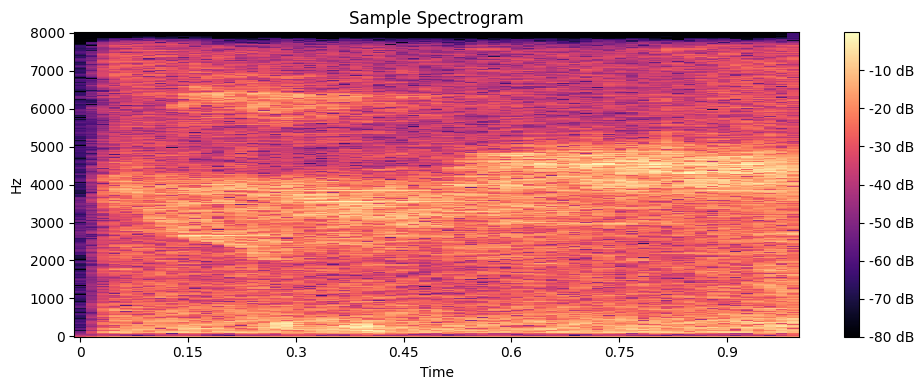

In [34]:

# Example: Plot spectrogram of the first sample
for batch in dataset.take(2):
    inputs, targets = batch
    audio_batch = inputs['audio']
    audio_np = audio_batch[0].numpy()
    plot_spectrogram(audio_np, title="Sample Spectrogram")
    break

In [19]:
class HarmonicSynthesizer(tf.keras.layers.Layer):
    def __init__(self, n_harmonics=60, sample_rate=16000):
        super(HarmonicSynthesizer, self).__init__()
        self.n_harmonics = n_harmonics
        self.sample_rate = sample_rate

    def call(self, f0_hz, amplitudes):
        """
        Synthesizes harmonic audio based on f0 and amplitudes.

        Args:
            f0_hz (tf.Tensor): Fundamental frequency tensor of shape [batch_size, frame_size].
            amplitudes (tf.Tensor): Amplitudes tensor of shape [batch_size, frame_size, n_harmonics].

        Returns:
            tf.Tensor: Synthesized harmonic audio of shape [batch_size, frame_size].
        """
        batch_size = tf.shape(f0_hz)[0]
        time_steps = tf.shape(f0_hz)[1]
        harmonic_numbers = tf.range(1, self.n_harmonics + 1, dtype=tf.float32)
        harmonic_numbers = tf.reshape(harmonic_numbers, [1, 1, -1])  # Shape: [1, 1, n_harmonics]
        f0_expanded = tf.expand_dims(f0_hz, -1)  # Shape: [batch_size, frame_size, 1]
        harmonic_frequencies = f0_expanded * harmonic_numbers  # Shape: [batch_size, frame_size, n_harmonics]

        # Phase accumulation
        phases = 2 * np.pi * tf.cumsum(harmonic_frequencies / self.sample_rate, axis=1)  # Integrate frequencies
        sine_waves = tf.sin(phases)  # Shape: [batch_size, frame_size, n_harmonics]

        # Weighted sum of sine waves
        audio = tf.reduce_sum(sine_waves * amplitudes, axis=-1)  # Shape: [batch_size, frame_size]
        return audio


In [20]:


class NoiseSynthesizer(tf.keras.layers.Layer):
    def __init__(self, n_filters=65):
        super(NoiseSynthesizer, self).__init__()
        self.n_filters = n_filters

    def call(self, noise_magnitudes):
        """
        Synthesizes noise audio based on noise magnitudes.

        Args:
            noise_magnitudes (tf.Tensor): Noise magnitudes tensor of shape [batch_size, frame_size, n_noise_bins].

        Returns:
            tf.Tensor: Synthesized noise audio of shape [batch_size, frame_size].
        """
        # Generate white noise
        batch_size = tf.shape(noise_magnitudes)[0]
        frame_size = tf.shape(noise_magnitudes)[1]
        noise = tf.random.normal([batch_size, frame_size, self.n_filters], mean=0.0, stddev=1.0)

        # Apply noise magnitudes
        noise = noise * noise_magnitudes  # Shape: [batch_size, frame_size, n_noise_bins]

        # Sum across noise bins
        audio = tf.reduce_sum(noise, axis=-1)  # Shape: [batch_size, frame_size]
        return audio


In [21]:
class ADSREnvelope(tf.keras.layers.Layer):
    def __init__(self, attack=0.1, decay=0.1, sustain=0.7, release=0.2, sample_rate=16000):
        super(ADSREnvelope, self).__init__()
        self.attack = attack
        self.decay = decay
        self.sustain = sustain
        self.release = release
        self.sample_rate = sample_rate

    def call(self, signal):
        """
        Applies an ADSR envelope to the signal.

        Args:
            signal (tf.Tensor): Audio signal tensor of shape [batch_size, signal_length].

        Returns:
            tf.Tensor: Envelope-shaped audio signal of shape [batch_size, signal_length].
        """
        total_samples = tf.shape(signal)[1]
        duration = tf.cast(total_samples, tf.float32) / self.sample_rate

        # Time vector
        t = tf.linspace(0.0, duration, total_samples)

        # ADSR envelope calculation
        envelope = tf.where(
            t < self.attack,
            t / self.attack,
            tf.where(
                t < self.attack + self.decay,
                1.0 - ((t - self.attack) / self.decay) * (1.0 - self.sustain),
                tf.where(
                    t < duration - self.release,
                    self.sustain,
                    self.sustain * (1.0 - (t - (duration - self.release)) / self.release)
                )
            )
        )
        envelope = tf.expand_dims(envelope, 0)  # Shape: [1, signal_length]
        return signal * envelope


In [ ]:
class F0Encoder(tf.keras.layers.Layer):
    def __init__(self):
        super(F0Encoder, self).__init__()

    def call(self, audio, sample_rate=16000, frame_rate=250):
        """
        Extracts F0 using the CREPE model.

        Args:
            audio (tf.Tensor): Audio tensor of shape [batch_size, audio_length].

        Returns:
            tf.Tensor: F0 tensor of shape [batch_size, frame_rate].
        """
        batch_size = tf.shape(audio)[0]
        f0_list = []
        for i in range(batch_size):
            audio_np = audio[i].numpy()
            # CREPE expects audio in float32 numpy array
            f0, confidence, _ = crepe.predict(audio_np, sample_rate, viterbi=True, step_size=int(1000 / frame_rate))
            # Apply confidence threshold
            f0 = np.where(confidence >= 0.85, f0, 0.0)
            f0_list.append(f0[:frame_rate])
        f0_tensor = tf.convert_to_tensor(f0_list, dtype=tf.float32)
        return f0_tensor


In [22]:
class LoudnessEncoder(tf.keras.layers.Layer):
    def __init__(self):
        super(LoudnessEncoder, self).__init__()

    def call(self, audio, sample_rate=16000, frame_rate=250, n_fft=1024):
        """
        Extracts loudness from audio.

        Args:
            audio (tf.Tensor): Audio tensor of shape [batch_size, audio_length].

        Returns:
            tf.Tensor: Loudness tensor of shape [batch_size, frame_rate].
        """
        batch_size = tf.shape(audio)[0]
        loudness_list = []
        for i in range(batch_size):
            audio_np = audio[i].numpy()
            S = np.abs(librosa.stft(audio_np, n_fft=n_fft, hop_length=sample_rate // frame_rate))
            loudness = librosa.amplitude_to_db(S, ref=np.max)
            loudness = loudness.mean(axis=0)  # Average across frequency bands
            loudness_list.append(loudness[:frame_rate])
        loudness_tensor = tf.convert_to_tensor(loudness_list, dtype=tf.float32)
        return loudness_tensor





In [ ]:
class ZEncoder(tf.keras.layers.Layer):
    def __init__(self, latent_dim=16):
        super(ZEncoder, self).__init__()
        self.mfcc_num = 30
        self.gru_units = 512
        self.gru = tf.keras.layers.GRU(self.gru_units, return_sequences=True, activation='selu')
        self.dense = tf.keras.layers.Dense(latent_dim, activation='selu')

    def call(self, audio, sample_rate=16000, frame_rate=250, n_fft=1024):
        """
        Encodes residual information from audio.

        Args:
            audio (tf.Tensor): Audio tensor of shape [batch_size, audio_length].

        Returns:
            tf.Tensor: Z tensor of shape [batch_size, frame_rate, latent_dim].
        """
        batch_size = tf.shape(audio)[0]
        z_list = []
        for i in range(batch_size):
            audio_np = audio[i].numpy()
            # Extract MFCCs
            mfcc = librosa.feature.mfcc(y=audio_np, sr=sample_rate, n_mfcc=self.mfcc_num, n_fft=n_fft, hop_length=sample_rate // frame_rate)
            mfcc = mfcc.T  # Shape: [frame_rate, mfcc_num]
            # Ensure correct shape
            if mfcc.shape[0] < frame_rate:
                pad_width = frame_rate - mfcc.shape[0]
                mfcc = np.pad(mfcc, ((0, pad_width), (0, 0)), mode='constant')
            else:
                mfcc = mfcc[:frame_rate]
            mfcc = np.expand_dims(mfcc, axis=0)  # Shape: [1, frame_rate, mfcc_num]
            # Pass through GRU and Dense layers
            z = self.gru(tf.convert_to_tensor(mfcc, dtype=tf.float32))  # Shape: [1, frame_rate, gru_units]
            z = self.dense(z)  # Shape: [1, frame_rate, latent_dim]
            z_list.append(z[0].numpy())
        z_tensor = tf.convert_to_tensor(z_list, dtype=tf.float32)
        return z_tensor


In [23]:
class DDSPAutoencoder(tf.keras.Model):
    def __init__(self, sample_rate=16000, n_harmonics=60, n_noise_bins=65, frame_size=250, latent_dim=16):
        super(DDSPAutoencoder, self).__init__()
        self.sample_rate = sample_rate
        self.n_harmonics = n_harmonics
        self.n_noise_bins = n_noise_bins
        self.frame_size = frame_size
        self.latent_dim = latent_dim

        # Encoders
        self.f0_encoder = F0Encoder()
        self.loudness_encoder = LoudnessEncoder()
        self.z_encoder = ZEncoder(latent_dim=latent_dim)

        # Decoder
        self.decoder = Decoder(n_harmonics=n_harmonics, n_noise_bins=n_noise_bins, latent_dim=latent_dim)

        # Synthesizers
        self.harmonic_synth = HarmonicSynthesizer(n_harmonics=n_harmonics, sample_rate=sample_rate)
        self.noise_synth = NoiseSynthesizer(n_filters=n_noise_bins)

        # ADSR Envelope
        self.envelope = ADSREnvelope(sample_rate=sample_rate)

        # Upsampling Layer (frame_size * hop_length = 250 * 64 = 16000)
        self.upsample = tf.keras.layers.UpSampling1D(size=64, interpolation='linear')

    def call(self, inputs):
        """
        Forward pass of the autoencoder.

        Args:
            inputs (dict): Dictionary containing 'audio'.

        Returns:
            tf.Tensor: Reconstructed audio of shape [batch_size, 16000].
        """
        audio = inputs['audio']          # Shape: [batch_size, 16000]

        # Extract F0 and Loudness
        f0 = self.f0_encoder(audio)       # Shape: [batch_size, frame_size]
        loudness = self.loudness_encoder(audio)  # Shape: [batch_size, frame_size]

        # Encode Z
        z = self.z_encoder(audio)         # Shape: [batch_size, frame_size, latent_dim]

        # Decode to get amplitudes and noise magnitudes
        amplitudes, noise_magnitudes = self.decoder(f0, loudness, z)  # Shapes: [batch_size, frame_size, n_harmonics], [batch_size, frame_size, n_noise_bins]

        # Synthesize Harmonic and Noise Audio
        harmonic_audio = self.harmonic_synth(f0, amplitudes)  # Shape: [batch_size, frame_size]
        noise_audio = self.noise_synth(noise_magnitudes)      # Shape: [batch_size, frame_size]

        # Combine Harmonic and Noise Components
        audio_out = harmonic_audio + noise_audio           # Shape: [batch_size, frame_size]

        # Upsample to audio length
        audio_out = tf.expand_dims(audio_out, -1)          # Shape: [batch_size, frame_size, 1]
        audio_out = self.upsample(audio_out)               # Shape: [batch_size, audio_length, 1]
        audio_out = tf.squeeze(audio_out, axis=-1)         # Shape: [batch_size, audio_length]

        # Apply ADSR Envelope
        audio_out = self.envelope(audio_out)               # Shape: [batch_size, audio_length]

        return audio_out


In [24]:
class DDSPAutoencoder(tf.keras.Model):
    def __init__(self, sample_rate=16000, n_harmonics=60, n_noise_bins=65, frame_size=250, latent_dim=16):
        super(DDSPAutoencoder, self).__init__()
        self.sample_rate = sample_rate
        self.n_harmonics = n_harmonics
        self.n_noise_bins = n_noise_bins
        self.frame_size = frame_size
        self.latent_dim = latent_dim

        # Encoders
        self.f0_encoder = F0Encoder()
        self.loudness_encoder = LoudnessEncoder()
        self.z_encoder = ZEncoder(latent_dim=latent_dim)

        # Decoder
        self.decoder = Decoder(n_harmonics=n_harmonics, n_noise_bins=n_noise_bins, latent_dim=latent_dim)

        # Synthesizers
        self.harmonic_synth = HarmonicSynthesizer(n_harmonics=n_harmonics, sample_rate=sample_rate)
        self.noise_synth = NoiseSynthesizer(n_filters=n_noise_bins)

        # ADSR Envelope
        self.envelope = ADSREnvelope(sample_rate=sample_rate)

        # Upsampling Layer (frame_size * hop_length = 250 * 64 = 16000)
        self.upsample = tf.keras.layers.UpSampling1D(size=64, interpolation='linear')

    def call(self, inputs):
        """
        Forward pass of the autoencoder.

        Args:
            inputs (dict): Dictionary containing 'audio'.

        Returns:
            tf.Tensor: Reconstructed audio of shape [batch_size, 16000].
        """
        audio = inputs['audio']          # Shape: [batch_size, 16000]

        # Extract F0 and Loudness
        f0 = self.f0_encoder(audio)       # Shape: [batch_size, frame_size]
        loudness = self.loudness_encoder(audio)  # Shape: [batch_size, frame_size]

        # Encode Z
        z = self.z_encoder(audio)         # Shape: [batch_size, frame_size, latent_dim]

        # Decode to get amplitudes and noise magnitudes
        amplitudes, noise_magnitudes = self.decoder(f0, loudness, z)  # Shapes: [batch_size, frame_size, n_harmonics], [batch_size, frame_size, n_noise_bins]

        # Synthesize Harmonic and Noise Audio
        harmonic_audio = self.harmonic_synth(f0, amplitudes)  # Shape: [batch_size, frame_size]
        noise_audio = self.noise_synth(noise_magnitudes)      # Shape: [batch_size, frame_size]

        # Combine Harmonic and Noise Components
        audio_out = harmonic_audio + noise_audio           # Shape: [batch_size, frame_size]

        # Upsample to audio length
        audio_out = tf.expand_dims(audio_out, -1)          # Shape: [batch_size, frame_size, 1]
        audio_out = self.upsample(audio_out)               # Shape: [batch_size, audio_length, 1]
        audio_out = tf.squeeze(audio_out, axis=-1)         # Shape: [batch_size, audio_length]

        # Apply ADSR Envelope
        audio_out = self.envelope(audio_out)               # Shape: [batch_size, audio_length]

        return audio_out




In [25]:
class DDSPAutoencoder(tf.keras.Model):
    def __init__(self, sample_rate=16000, n_harmonics=60, n_noise_bins=65, frame_size=250, latent_dim=16):
        super(DDSPAutoencoder, self).__init__()
        self.encoder = DDSPEncoder(latent_dim=latent_dim)
        self.decoder = DDSPDecoder(n_harmonics=n_harmonics, n_noise_bins=n_noise_bins, frame_size=frame_size)
        self.harmonic_synth = HarmonicSynthesizer(n_harmonics=n_harmonics, sample_rate=sample_rate)
        self.noise_synth = NoiseSynthesizer(n_frames=frame_size, n_filters=n_noise_bins)
        self.envelope = ADSREnvelope(sample_rate=sample_rate)
        self.reverb = Reverb()

        # Upsampling layer to convert 250 frames to 16000 samples (250 * 64 = 16000)
        self.upsample = tf.keras.layers.UpSampling1D(size=64)  # Defaults to 'nearest' interpolation

    def call(self, inputs):
        """
        Forward pass of the autoencoder.

        Args:
            inputs (dict): Dictionary containing 'audio', 'f0_hz', and 'loudness'.

        Returns:
            tf.Tensor: Reconstructed audio of shape [batch_size, 16000].
        """
        audio = inputs['audio']      # Shape: [batch_size, 16000]
        f0_hz = inputs['f0_hz']      # Shape: [batch_size, 250]
        loudness = inputs['loudness']# Shape: [batch_size, 250]

        # Encode
        z = self.encoder(audio)  # Shape: [batch_size, latent_dim]

        # Decode
        amplitudes, noise_magnitudes = self.decoder(z, f0_hz, loudness)  # Shapes: [batch_size, 250, n_harmonics], [batch_size, 250, n_noise_bins]

        # Synthesize harmonic and noise audio
        harmonic_audio = self.harmonic_synth(f0_hz, amplitudes)  # Shape: [batch_size, 250]
        noise_audio = self.noise_synth(noise_magnitudes)         # Shape: [batch_size, 250]

        # Combine harmonic and noise components
        audio_out = harmonic_audio + noise_audio  # Shape: [batch_size, 250]

        # Upsample to 16000 samples
        audio_out = tf.expand_dims(audio_out, -1)        # Shape: [batch_size, 250, 1]
        audio_out = self.upsample(audio_out)             # Shape: [batch_size, 16000, 1]
        audio_out = tf.squeeze(audio_out, axis=-1)       # Shape: [batch_size, 16000]

        # Apply ADSR envelope and reverb
        audio_out = self.envelope(audio_out)       # Shape: [batch_size, 16000]
        audio_out = self.reverb(audio_out)         # Shape: [batch_size, 16000]

        return audio_out

In [26]:
autoencoder = DDSPAutoencoder(sample_rate=16000, n_harmonics=60, n_noise_bins=65, frame_size=250, latent_dim=16)

In [27]:
def spectral_loss(y_true, y_pred, sample_rate=16000, n_fft=1024, hop_length=256):
    """
    Computes the spectral loss between true and predicted audio.

    Args:
        y_true (tf.Tensor): Ground truth audio of shape [batch_size, 16000].
        y_pred (tf.Tensor): Predicted audio of shape [batch_size, 16000].
        sample_rate (int): Sampling rate.
        n_fft (int): FFT window size.
        hop_length (int): Hop length.

    Returns:
        tf.Tensor: Scalar loss value.
    """
    # Compute STFTs
    S_true = tf.abs(tf.signal.stft(y_true, frame_length=n_fft, frame_step=hop_length))
    S_pred = tf.abs(tf.signal.stft(y_pred, frame_length=n_fft, frame_step=hop_length))

    # Compute log magnitude spectrograms
    log_S_true = tf.math.log(S_true + 1e-7)
    log_S_pred = tf.math.log(S_pred + 1e-7)

    # Compute L1 loss
    loss = tf.reduce_mean(tf.abs(log_S_true - log_S_pred))
    return loss



In [28]:
# Define the optimizer
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)

# Compile the model
autoencoder.compile(optimizer=optimizer, loss=spectral_loss)

# Train the model
epochs = 10  # Adjust based on your needs
# Train the model
history = autoencoder.fit(
    dataset,
    epochs=epochs,
   
)

Epoch 1/10


I0000 00:00:1732450705.762024     104 service.cc:145] XLA service 0x7aa99800d730 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1732450705.762107     104 service.cc:153]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1732450710.602776     104 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


933/933 ━━━━━━━━━━━━━━━━━━━━ 305s 318ms/step - loss: 3.1233
Epoch 2/10


/opt/conda/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


933/933 ━━━━━━━━━━━━━━━━━━━━ 295s 316ms/step - loss: 2.4009
Epoch 3/10
933/933 ━━━━━━━━━━━━━━━━━━━━ 298s 320ms/step - loss: 1.9207
Epoch 4/10
933/933 ━━━━━━━━━━━━━━━━━━━━ 304s 325ms/step - loss: 1.7603
Epoch 5/10
933/933 ━━━━━━━━━━━━━━━━━━━━ 308s 331ms/step - loss: 1.6598
Epoch 6/10
933/933 ━━━━━━━━━━━━━━━━━━━━ 300s 321ms/step - loss: 1.4741
Epoch 7/10
933/933 ━━━━━━━━━━━━━━━━━━━━ 301s 322ms/step - loss: 1.3444
Epoch 8/10
933/933 ━━━━━━━━━━━━━━━━━━━━ 295s 316ms/step - loss: 1.4680
Epoch 9/10
933/933 ━━━━━━━━━━━━━━━━━━━━ 303s 325ms/step - loss: 1.3149
Epoch 10/10
933/933 ━━━━━━━━━━━━━━━━━━━━ 302s 324ms/step - loss: 1.3057


Input Audio Shape: (8, 16000)
Predicted Audio Shape: (8, 16000)
Target Audio Shape: (8, 16000)


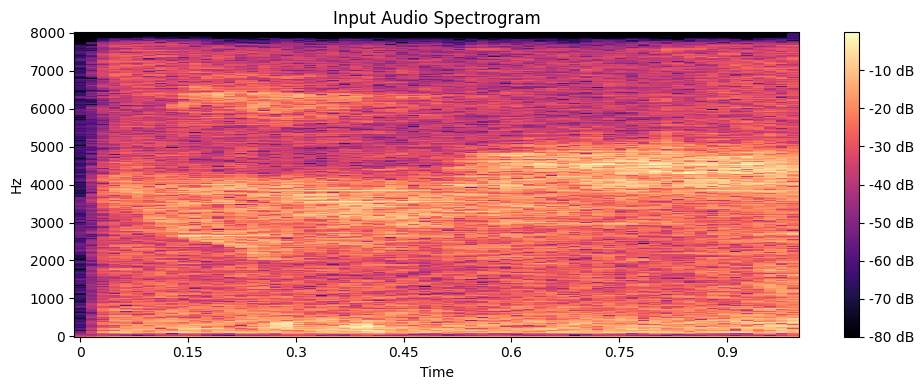

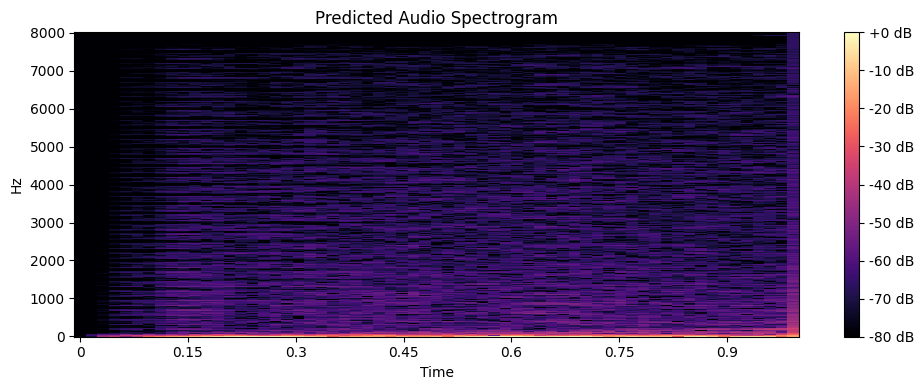

In [29]:


# Retrieve a single batch from the dataset
for batch in dataset.take(1):
    inputs, targets = batch
    break

# Run the model on the batch
predictions = autoencoder(inputs)

# Check the shapes
print(f"Input Audio Shape: {inputs['audio'].shape}")        # Expected: (batch_size, 16000)
print(f"Predicted Audio Shape: {predictions.shape}")       # Expected: (batch_size, 16000)
print(f"Target Audio Shape: {targets.shape}")              # Expected: (batch_size, 16000)")

# Plot spectrogram of input and predicted audio for the first sample
input_audio = inputs['audio'][0].numpy()
predicted_audio = predictions[0].numpy()

plot_spectrogram(input_audio, title="Input Audio Spectrogram")
plot_spectrogram(predicted_audio, title="Predicted Audio Spectrogram")



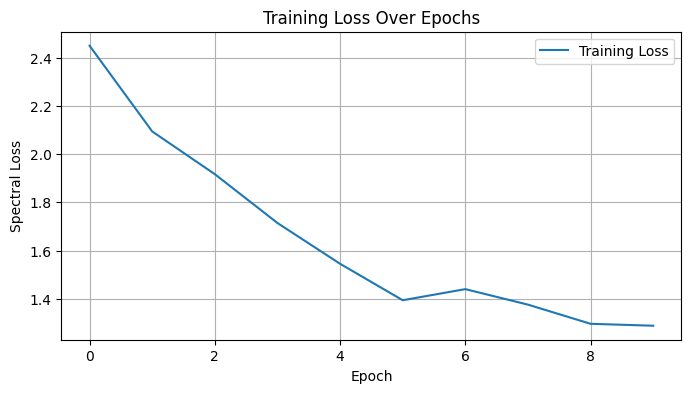

In [30]:
# Plot the training loss
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Training Loss')
plt.title('Training Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Spectral Loss')
plt.legend()
plt.grid(True)
plt.show()

Playing Original Audio:


Playing Reconstructed Audio:


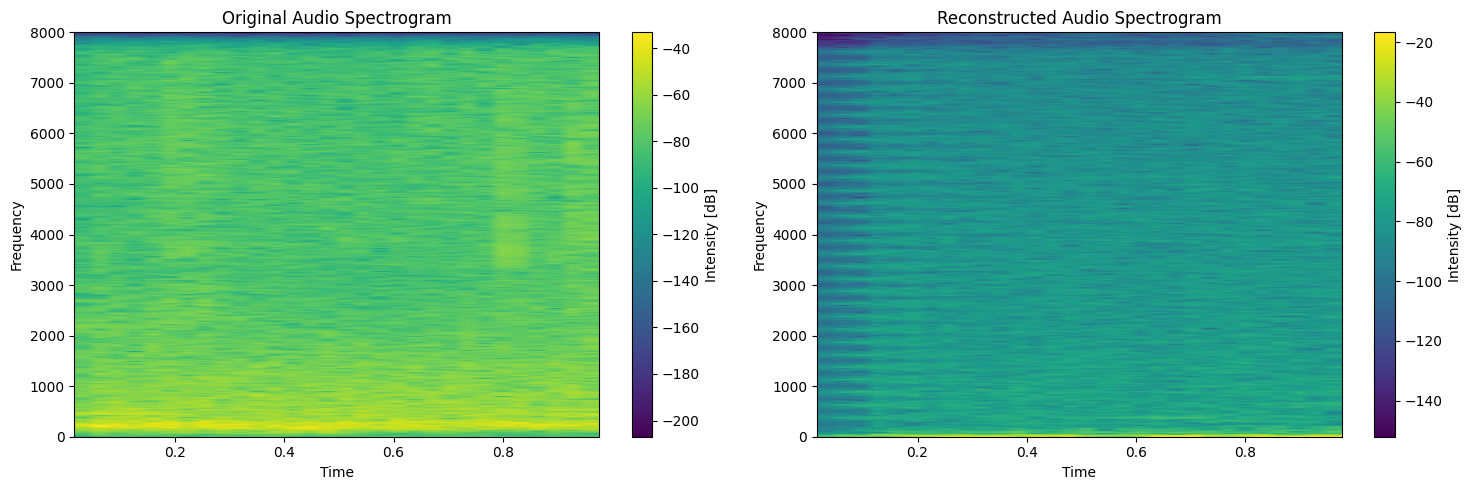

In [31]:
import tensorflow as tf
import numpy as np
from IPython.display import Audio, display
import matplotlib.pyplot as plt

def compare_original_and_generated(autoencoder, dataset, sample_rate=16000):
    """
    Retrieves a sample from the dataset, plays the original audio,
    reconstructs it using the autoencoder, and plays the reconstructed audio.

    Args:
        autoencoder (tf.keras.Model): Trained DDSP autoencoder model.
        dataset (tf.data.Dataset): Preprocessed and batched dataset.
        sample_rate (int): Sampling rate for the audio.
    """
    # Get one batch from the dataset
    for batch in dataset.take(1):
        inputs, targets = batch
        audio_batch = inputs['audio']
        f0_batch = inputs['f0_hz']
        loudness_batch = inputs['loudness']
        break  # We only need one batch

    # Select a sample from the batch
    idx = np.random.randint(0, audio_batch.shape[0])
    audio = tf.expand_dims(audio_batch[idx], axis=0)        # Shape: [1, 16000]
    f0_hz = tf.expand_dims(f0_batch[idx], axis=0)          # Shape: [1, 250]
    loudness = tf.expand_dims(loudness_batch[idx], axis=0) # Shape: [1, 250]

    # Play the original audio
    print("Playing Original Audio:")
    original_audio_np = audio.numpy()[0]
    display(Audio(original_audio_np, rate=sample_rate))

    # Reconstruct the audio using the autoencoder (without perturbing the latent vector)
    # Encode the audio to get the latent vector
    z = autoencoder.encoder(audio)

    # Decode the latent vector
    amplitudes, noise_magnitudes = autoencoder.decoder(z, f0_hz, loudness)

    # Synthesize harmonic and noise audio
    harmonic_audio = autoencoder.harmonic_synth(f0_hz, amplitudes)
    noise_audio = autoencoder.noise_synth(noise_magnitudes)

    # Combine harmonic and noise components
    audio_out = harmonic_audio + noise_audio

    # Upsample to 16000 samples
    audio_out = tf.expand_dims(audio_out, -1)
    audio_out = autoencoder.upsample(audio_out)
    audio_out = tf.squeeze(audio_out, axis=-1)

    # Apply ADSR envelope and reverb
    audio_out = autoencoder.envelope(audio_out)
    audio_out = autoencoder.reverb(audio_out)

    # Get the reconstructed audio
    reconstructed_audio_np = audio_out.numpy()[0]

    # Normalize audio to prevent clipping
    max_val = np.max(np.abs(reconstructed_audio_np))
    if max_val > 0:
        reconstructed_audio_np = reconstructed_audio_np / max_val

    # Play the reconstructed audio
    print("Playing Reconstructed Audio:")
    display(Audio(reconstructed_audio_np, rate=sample_rate))

    # Optionally, plot spectrograms for comparison
    plot_spectrograms(original_audio_np, reconstructed_audio_np, sample_rate)

def plot_spectrograms(original_audio, reconstructed_audio, sample_rate=16000):
    """
    Plots spectrograms of the original and reconstructed audio for comparison.

    Args:
        original_audio (numpy.array): Original audio array.
        reconstructed_audio (numpy.array): Reconstructed audio array.
        sample_rate (int): Sampling rate of the audio.
    """
    plt.figure(figsize=(15, 5))

    # Original audio spectrogram
    plt.subplot(1, 2, 1)
    plt.title("Original Audio Spectrogram")
    plt.specgram(original_audio, Fs=sample_rate, NFFT=1024, noverlap=512)
    plt.xlabel('Time')
    plt.ylabel('Frequency')
    plt.colorbar(label='Intensity [dB]')

    # Reconstructed audio spectrogram
    plt.subplot(1, 2, 2)
    plt.title("Reconstructed Audio Spectrogram")
    plt.specgram(reconstructed_audio, Fs=sample_rate, NFFT=1024, noverlap=512)
    plt.xlabel('Time')
    plt.ylabel('Frequency')
    plt.colorbar(label='Intensity [dB]')

    plt.tight_layout()
    plt.show()

# Usage
compare_original_and_generated(autoencoder, dataset)




In [32]:
# Get a single file path
test_file_path = audio_files[0]

# Convert to tensor
test_file_path_tensor = tf.constant(test_file_path)

# Preprocess the audio
audio, f0_hz, loudness = preprocess_audio(test_file_path_tensor)

# Check the outputs
print("Audio shape:", audio.shape)
print("F0_hz shape:", f0_hz.shape)
print("Loudness shape:", loudness.shape)

Audio shape: (16000,)
F0_hz shape: (250,)
Loudness shape: (250,)


In [41]:
# Iterate through a few batches and verify shapes
for batch in dataset.take(2):
    inputs, targets = batch
    audio_batch = inputs['audio']
    f0_batch = inputs['f0_hz']
    loudness_batch = inputs['loudness']
    targets_batch = targets

    print(f"Audio Batch Shape: {audio_batch.shape}")        # Expected: (batch_size, 16000)
    print(f"F0 Batch Shape: {f0_batch.shape}")              # Expected: (batch_size, 250)
    print(f"Loudness Batch Shape: {loudness_batch.shape}")  # Expected: (batch_size, 250)
    print(f"Targets Batch Shape: {targets_batch.shape}")    # Expected: (batch_size, 16000)")
    print("-" * 50)


Audio Batch Shape: (8, 16000)
F0 Batch Shape: (8, 250)
Loudness Batch Shape: (8, 250)
Targets Batch Shape: (8, 16000)
--------------------------------------------------
Audio Batch Shape: (8, 16000)
F0 Batch Shape: (8, 250)
Loudness Batch Shape: (8, 250)
Targets Batch Shape: (8, 16000)
--------------------------------------------------


Playing Original Audio:



Generating Variation 1:
 - Pitch shifted up by one octave.


Generated variation saved to generated_variations/variation_1.wav


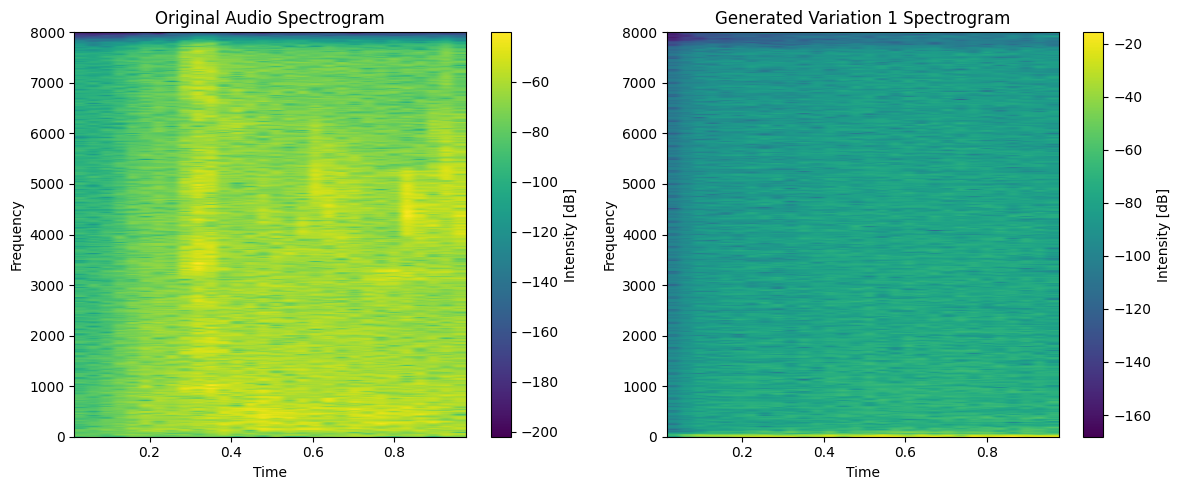


Generating Variation 2:
 - Pitch shifted down by a perfect fifth.


Generated variation saved to generated_variations/variation_2.wav


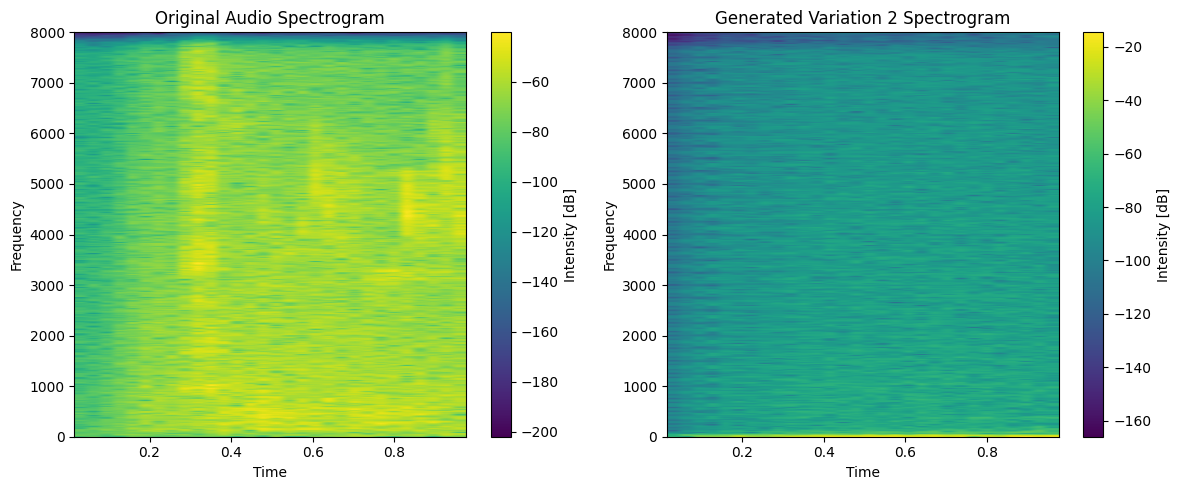


Generating Variation 3:
 - Loudness increased by 10 dB.


Generated variation saved to generated_variations/variation_3.wav


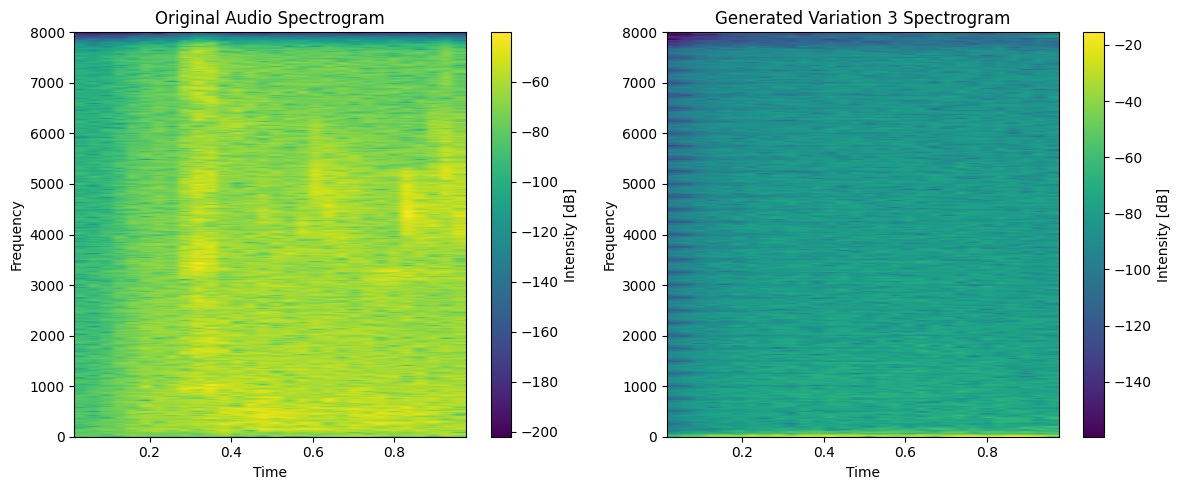


Generating Variation 4:
 - Latent vector perturbed with random noise.


Generated variation saved to generated_variations/variation_4.wav


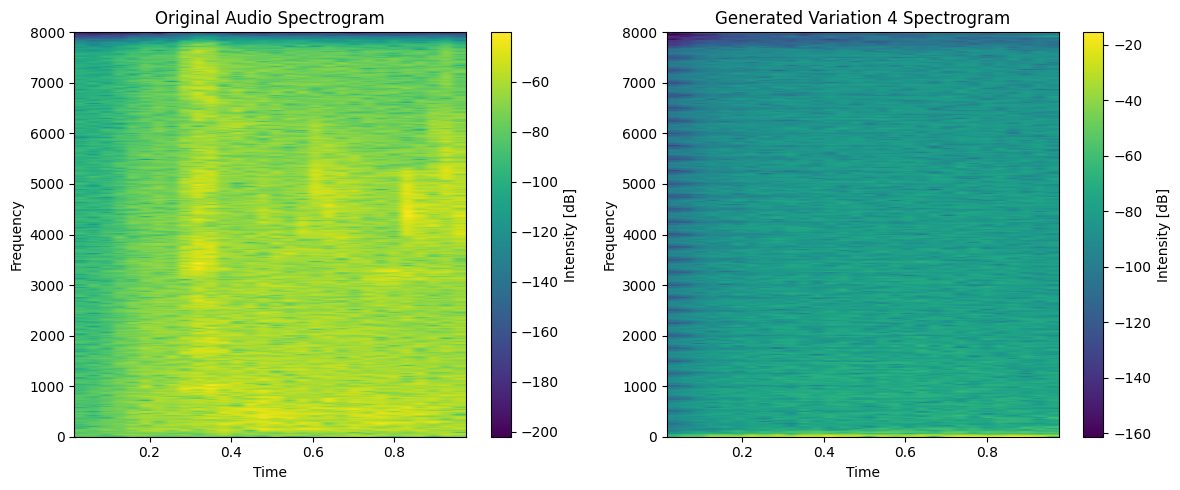


Generating Variation 5:
 - Background noise enhanced.


Generated variation saved to generated_variations/variation_5.wav


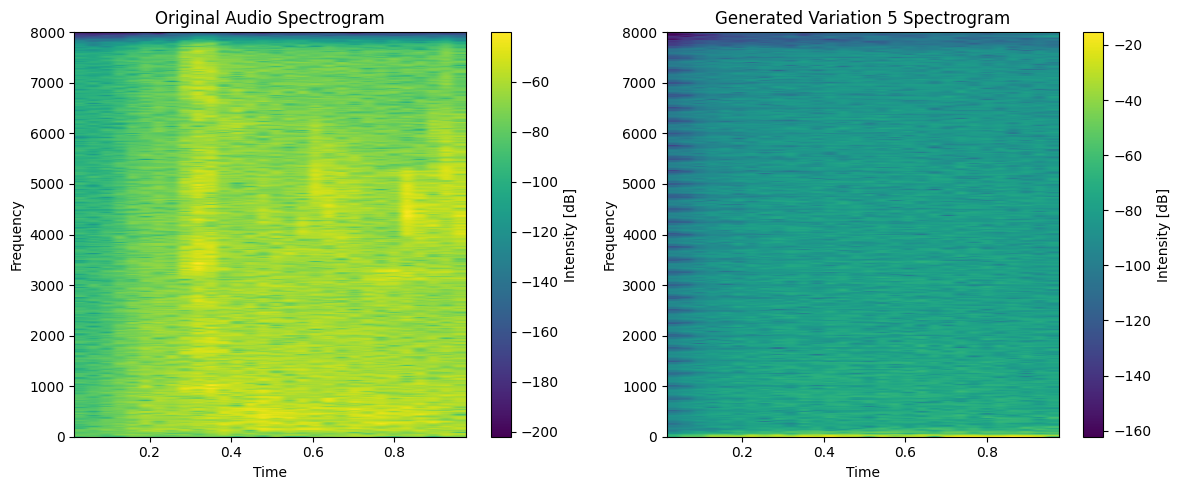

In [33]:
import tensorflow as tf
import numpy as np
from IPython.display import Audio, display
import matplotlib.pyplot as plt
import soundfile as sf
import os

def generate_variations_from_single_sound(autoencoder, dataset, num_variations=5, sample_rate=16000, output_dir='generated_variations'):
    """
    Generates multiple variations from a single audio sample by modifying pitch, loudness, and other parameters.

    Args:
        autoencoder (tf.keras.Model): Trained DDSP autoencoder model.
        dataset (tf.data.Dataset): Preprocessed and batched dataset.
        num_variations (int): Number of variations to generate.
        sample_rate (int): Sampling rate for the audio.
        output_dir (str): Directory to save the generated sounds.
    """
    os.makedirs(output_dir, exist_ok=True)

    # Get one batch from the dataset
    for batch in dataset.take(1):
        inputs, _ = batch
        audio_batch = inputs['audio']
        f0_batch = inputs['f0_hz']
        loudness_batch = inputs['loudness']
        break  # We only need one batch

    # Select a sample from the batch
    idx = np.random.randint(0, audio_batch.shape[0])
    audio = tf.expand_dims(audio_batch[idx], axis=0)        # Shape: [1, 16000]
    f0_hz = tf.expand_dims(f0_batch[idx], axis=0)          # Shape: [1, 250]
    loudness = tf.expand_dims(loudness_batch[idx], axis=0) # Shape: [1, 250]

    # Play the original audio
    print("Playing Original Audio:")
    original_audio_np = audio.numpy()[0]
    display(Audio(original_audio_np, rate=sample_rate))

    # Encode the audio to get the latent vector
    z = autoencoder.encoder(audio)

    # Generate variations
    for i in range(num_variations):
        print(f"\nGenerating Variation {i+1}:")
        # Start with the original z, f0_hz, and loudness
        z_var = tf.identity(z)
        f0_hz_var = tf.identity(f0_hz)
        loudness_var = tf.identity(loudness)

        # Modify the latent vector or conditioning inputs
        if i == 0:
            # Variation 1: Shift pitch up by one octave (multiply f0_hz by 2)
            f0_hz_var = f0_hz_var * 2.0
            print(" - Pitch shifted up by one octave.")
        elif i == 1:
            # Variation 2: Shift pitch down by a perfect fifth (multiply f0_hz by 2/3)
            f0_hz_var = f0_hz_var * (2/3)
            print(" - Pitch shifted down by a perfect fifth.")
        elif i == 2:
            # Variation 3: Increase loudness
            loudness_var = loudness_var + 10.0  # Increase loudness by 10 dB
            print(" - Loudness increased by 10 dB.")
        elif i == 3:
            # Variation 4: Add random noise to the latent vector
            z_var = z_var + tf.random.normal(tf.shape(z_var), mean=0.0, stddev=0.5)
            print(" - Latent vector perturbed with random noise.")
        elif i == 4:
            # Variation 5: Modify noise magnitudes in the decoder to change background sound
            # Increase noise magnitudes to enhance background noise
            noise_scale = 1.5
            print(" - Background noise enhanced.")
        else:
            print(" - No modification applied.")

        # Decode the modified latent vector
        if i == 4:
            # For variation 5, modify the decoder outputs directly
            amplitudes_var, noise_magnitudes_var = autoencoder.decoder(z_var, f0_hz_var, loudness_var)
            noise_magnitudes_var = noise_magnitudes_var * noise_scale
        else:
            amplitudes_var, noise_magnitudes_var = autoencoder.decoder(z_var, f0_hz_var, loudness_var)

        # Synthesize harmonic and noise audio
        harmonic_audio_var = autoencoder.harmonic_synth(f0_hz_var, amplitudes_var)
        noise_audio_var = autoencoder.noise_synth(noise_magnitudes_var)

        # Combine harmonic and noise components
        audio_out_var = harmonic_audio_var + noise_audio_var

        # Upsample to 16000 samples
        audio_out_var = tf.expand_dims(audio_out_var, -1)
        audio_out_var = autoencoder.upsample(audio_out_var)
        audio_out_var = tf.squeeze(audio_out_var, axis=-1)

        # Apply ADSR envelope and reverb
        audio_out_var = autoencoder.envelope(audio_out_var)
        audio_out_var = autoencoder.reverb(audio_out_var)

        # Get the generated audio
        generated_audio_np = audio_out_var.numpy()[0]

        # Normalize audio to prevent clipping
        max_val = np.max(np.abs(generated_audio_np))
        if max_val > 0:
            generated_audio_np = generated_audio_np / max_val

        # Play the generated audio
        display(Audio(generated_audio_np, rate=sample_rate))

        # Save the generated audio
        output_path = os.path.join(output_dir, f'variation_{i+1}.wav')
        sf.write(output_path, generated_audio_np, sample_rate)
        print(f"Generated variation saved to {output_path}")

        # Optionally, plot spectrograms for each variation
        plot_spectrogram_comparison(original_audio_np, generated_audio_np, sample_rate, variation_num=i+1)

def plot_spectrogram_comparison(original_audio, generated_audio, sample_rate=16000, variation_num=1):
    """
    Plots spectrograms of the original and generated audio for comparison.

    Args:
        original_audio (numpy.array): Original audio array.
        generated_audio (numpy.array): Generated audio array.
        sample_rate (int): Sampling rate of the audio.
        variation_num (int): Variation number for labeling.
    """
    plt.figure(figsize=(12, 5))

    # Original audio spectrogram
    plt.subplot(1, 2, 1)
    plt.title("Original Audio Spectrogram")
    plt.specgram(original_audio, Fs=sample_rate, NFFT=1024, noverlap=512)
    plt.xlabel('Time')
    plt.ylabel('Frequency')
    plt.colorbar(label='Intensity [dB]')

    # Generated audio spectrogram
    plt.subplot(1, 2, 2)
    plt.title(f"Generated Variation {variation_num} Spectrogram")
    plt.specgram(generated_audio, Fs=sample_rate, NFFT=1024, noverlap=512)
    plt.xlabel('Time')
    plt.ylabel('Frequency')
    plt.colorbar(label='Intensity [dB]')

    plt.tight_layout()
    plt.show()

# Usage
generate_variations_from_single_sound(autoencoder, dataset, num_variations=5)


In [ ]:
import tensorflow as tf
print(tf.__version__)

In [ ]:
!pip install --upgrade tensorflow